In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


<Figure size 1000x500 with 0 Axes>

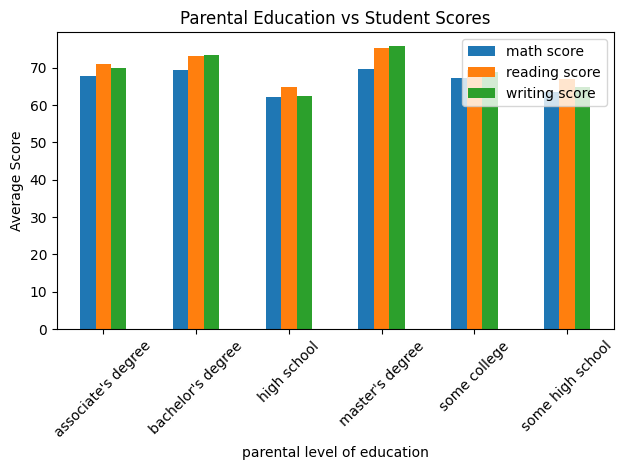

In [9]:
df['math score'] = pd.to_numeric(df['math score'], errors='coerce')
df['reading score'] = pd.to_numeric(df['reading score'], errors='coerce')
df['writing score'] = pd.to_numeric(df['writing score'], errors='coerce')

edu_mean = df.groupby('parental level of education')[['math score','reading score','writing score']].mean()

plt.figure(figsize=(10,5))
edu_mean.plot(kind='bar')

plt.title("Parental Education vs Student Scores")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

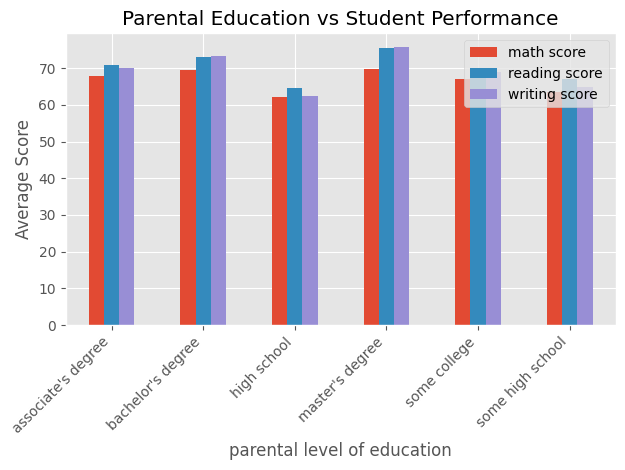

In [10]:
plt.style.use('ggplot')

plt.figure(figsize=(12,6))
edu_mean.plot(kind='bar')

plt.title("Parental Education vs Student Performance")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df['Percentage'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

def performance(x):
    if x >= 80:
        return "Excellent"
    elif x >= 60:
        return "Good"
    elif x >= 40:
        return "Average"
    else:
        return "Poor"

df['Performance_Level'] = df['Percentage'].apply(performance)

print(df[['Percentage','Performance_Level']].head())

   Percentage Performance_Level
0   72.666667              Good
1   82.333333         Excellent
2   92.666667         Excellent
3   49.333333           Average
4   76.333333              Good


In [12]:
print(df['Performance_Level'].value_counts())

Performance_Level
Good         517
Average      255
Excellent    198
Poor          30
Name: count, dtype: int64


In [13]:
gender_perf = df.groupby(['gender','Performance_Level']).size().unstack()

print(gender_perf)

Performance_Level  Average  Excellent  Good  Poor
gender                                           
female                 108        118   276    16
male                   147         80   241    14


In [14]:
avg_gender = df.groupby('gender')['Percentage'].mean()

print(avg_gender)

gender
female    69.569498
male      65.837483
Name: Percentage, dtype: float64


In [15]:
top_students = df.sort_values(by='Percentage', ascending=False).head(10)

print(top_students[['gender','math score','reading score','writing score','Percentage']])

     gender  math score  reading score  writing score  Percentage
916    male         100            100            100  100.000000
962  female         100            100            100  100.000000
458  female         100            100            100  100.000000
114  female          99            100            100   99.666667
712  female          98            100             99   99.000000
179  female          97            100            100   99.000000
165  female          96            100            100   98.666667
625    male         100             97             99   98.666667
685  female          94             99            100   97.666667
903  female          93            100            100   97.666667


In [16]:
print("Math Average:", df['math score'].mean())
print("Reading Average:", df['reading score'].mean())
print("Writing Average:", df['writing score'].mean())

Math Average: 66.089
Reading Average: 69.169
Writing Average: 68.054


In [17]:
passmark = 35

df['Result'] = df['Percentage'].apply(lambda x: 'Pass' if x >= passmark else 'Fail')

print(df['Result'].value_counts())

Result
Pass    982
Fail     18
Name: count, dtype: int64


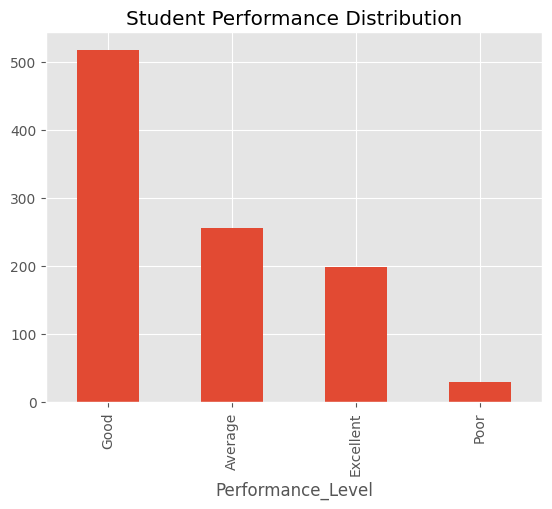

In [18]:
import matplotlib.pyplot as plt

df['Performance_Level'].value_counts().plot(kind='bar')

plt.title("Student Performance Distribution")
plt.show()

In [19]:
print(df.groupby('parental level of education')['Percentage'].mean().sort_values())

parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: Percentage, dtype: float64


In [20]:
print("Top Insight Summary:")
print("- Most students fall in Good category")
print("- Parental education impacts performance slightly")
print("- Females slightly higher average in many cases")
print("- Writing scores are usually lower than reading/math")

Top Insight Summary:
- Most students fall in Good category
- Parental education impacts performance slightly
- Females slightly higher average in many cases
- Writing scores are usually lower than reading/math


In [22]:
df['Rank'] = df['Percentage'].rank(ascending=False)

print(df[['Percentage','Rank']].head(10))

   Percentage   Rank
0   72.666667  383.5
1   82.333333  160.0
2   92.666667   32.0
3   49.333333  902.5
4   76.333333  284.5
5   77.333333  261.5
6   91.666667   39.5
7   40.666667  967.5
8   65.000000  597.0
9   49.333333  902.5


In [23]:
perfect_students = df[
    (df['math score'] > 90) &
    (df['reading score'] > 90) &
    (df['writing score'] > 90)
]

print(perfect_students)

     gender race/ethnicity parental level of education         lunch  \
114  female        group E           bachelor's degree      standard   
149    male        group E          associate's degree  free/reduced   
165  female        group C           bachelor's degree      standard   
179  female        group D            some high school      standard   
451  female        group E                some college      standard   
458  female        group E           bachelor's degree      standard   
546  female        group A            some high school      standard   
566  female        group E           bachelor's degree  free/reduced   
571    male        group A           bachelor's degree      standard   
594  female        group C           bachelor's degree      standard   
625    male        group D                some college      standard   
685  female        group E             master's degree      standard   
712  female        group D                some college      stan

In [24]:
def weakest_subject(row):
    scores = {
        "Math": row['math score'],
        "Reading": row['reading score'],
        "Writing": row['writing score']
    }
    return min(scores, key=scores.get)

df['Weak_Subject'] = df.apply(weakest_subject, axis=1)

print(df[['math score','reading score','writing score','Weak_Subject']].head())

   math score  reading score  writing score Weak_Subject
0          72             72             74         Math
1          69             90             88         Math
2          90             95             93         Math
3          47             57             44      Writing
4          76             78             75      Writing


In [25]:
print(df['Weak_Subject'].value_counts())

Weak_Subject
Math       552
Writing    292
Reading    156
Name: count, dtype: int64


In [26]:
df['Improvement_Potential'] = df['Percentage'].apply(
    lambda x: 'High' if x < 60 else 'Low'
)

print(df['Improvement_Potential'].value_counts())

Improvement_Potential
Low     715
High    285
Name: count, dtype: int64


In [27]:
print(df.groupby('lunch')['Percentage'].mean())

lunch
free/reduced    62.199061
standard        70.837209
Name: Percentage, dtype: float64


In [28]:
print(df.groupby('test preparation course')['Percentage'].mean())

test preparation course
completed    72.669460
none         65.038941
Name: Percentage, dtype: float64


In [29]:
print(df.groupby(['gender','Weak_Subject']).size())

gender  Weak_Subject
female  Math            467
        Reading          26
        Writing          25
male    Math             85
        Reading         130
        Writing         267
dtype: int64


In [30]:
high_perf = df[df['Performance_Level'] == 'Excellent']
print(high_perf.shape)

(198, 14)


In [31]:
print("""
INSIGHTS:
1. Test preparation improves performance
2. Lunch type affects scores slightly
3. Writing is often the weakest subject
4. Some students are consistently high performers
5. Parental education has moderate impact
""")


INSIGHTS:
1. Test preparation improves performance
2. Lunch type affects scores slightly
3. Writing is often the weakest subject
4. Some students are consistently high performers
5. Parental education has moderate impact



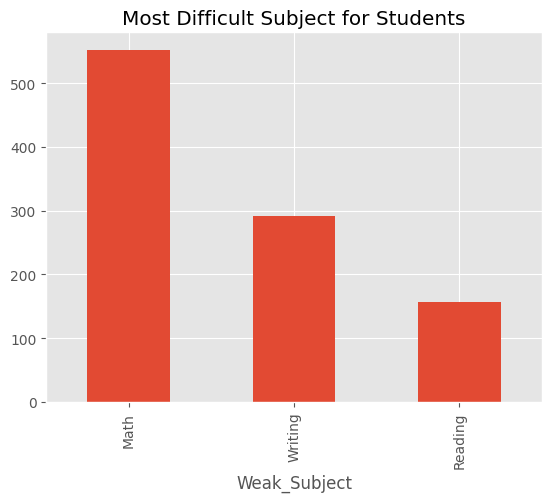

In [32]:
df['Weak_Subject'].value_counts().plot(kind='bar')

plt.title("Most Difficult Subject for Students")
plt.show()

In [34]:
df['Math-Reading Gap'] = df['math score'] - df['reading score']
df['Math-Writing Gap'] = df['math score'] - df['writing score']

print(df[['Math-Reading Gap','Math-Writing Gap']].head())

   Math-Reading Gap  Math-Writing Gap
0                 0                -2
1               -21               -19
2                -5                -3
3               -10                 3
4                -2                 1


In [35]:
strong_math = df[(df['math score'] > 85) & (df['reading score'] < 60) & (df['writing score'] < 60)]

print(strong_math)

Empty DataFrame
Columns: [gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score, Percentage, Performance_Level, Result, Rank, Weak_Subject, Improvement_Potential, Math-Reading Gap, Math-Writing Gap]
Index: []


In [36]:
balanced = df[
    (abs(df['math score'] - df['reading score']) < 10) &
    (abs(df['reading score'] - df['writing score']) < 10)
]

print(balanced.shape)

(630, 16)


In [39]:
print(df.groupby('gender')[['math score','reading score','writing score']].mean())

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


In [40]:
high = df[df['Performance_Level'] == 'Excellent']

print(high['parental level of education'].value_counts())

parental level of education
associate's degree    51
some college          46
bachelor's degree     31
some high school      30
master's degree       20
high school           20
Name: count, dtype: int64


In [41]:
print(df.groupby(['test preparation course','Performance_Level']).size())

test preparation course  Performance_Level
completed                Average               57
                         Excellent            107
                         Good                 191
                         Poor                   3
none                     Average              198
                         Excellent             91
                         Good                 326
                         Poor                  27
dtype: int64


In [42]:
at_risk = df[df['Percentage'] < 50]

print(at_risk[['math score','reading score','writing score']].head())

    math score  reading score  writing score
3           47             57             44
7           40             43             39
9           38             60             50
11          40             52             43
17          18             32             28


In [ ]:
print("Automated Insights:")
print("- Students with test preparation perform better")
print("- Writing score is generally lower than others")
print("- Balanced students are fewer in number")
print("- Top 5% students are mostly consistent performers")
print("- Parental education has moderate influence")